The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Realizations: 100%|██████████| 100/100 [03:59<00:00,  2.40s/it]


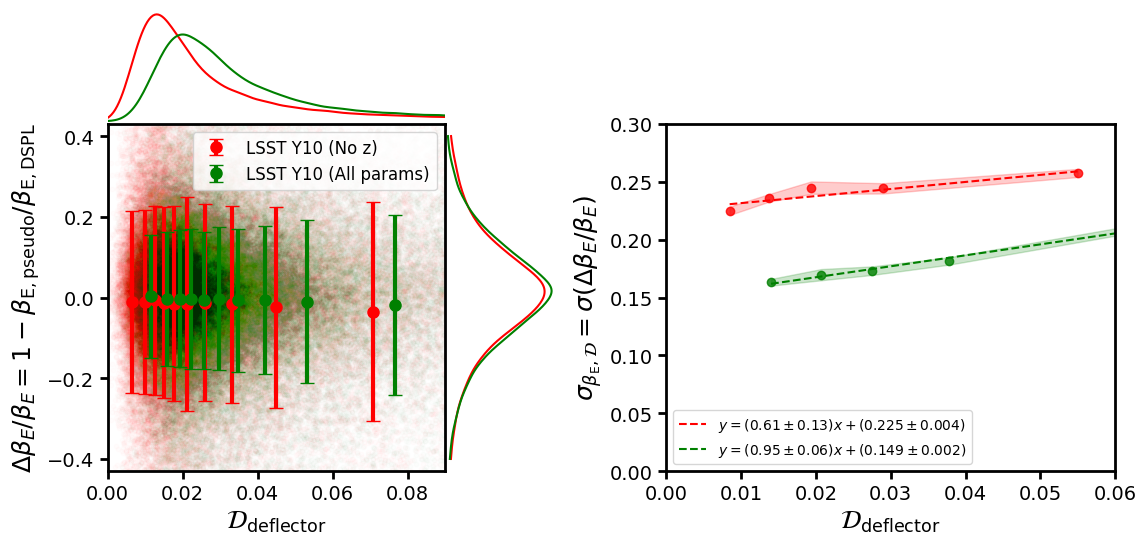

In [14]:
from pairing import (get_kdtree_pairs, get_pairs_table_PDSPL, inject_observational_errors, plot_beta_E_vs_D_MC, compute_dissimilarity)
import pickle
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

# 1. Load Data
base_key = 'lsst_y10'
with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    base_table = pickle.load(f)[base_key]['table']

# 2. Define Variations (Now with specific dissimilarity_keys per case)
variations = {
    'case_no_z': {
        'name': 'LSST Y10 (No z)',
        'keys': ['R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        'dissim_keys': ["rel_diff_R_e_arcsec", "rel_diff_mag_D_i", "rel_diff_color_D_gr", "rel_diff_color_D_ri"],
        'color': 'red'
    },
    'case_all': {
        'name': 'LSST Y10 (All params)',
        'keys': ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        'dissim_keys': ["rel_diff_z_D", "rel_diff_R_e_arcsec", "rel_diff_mag_D_i", "rel_diff_color_D_gr", "rel_diff_color_D_ri"],
        'color': 'green'
    }
}

# 3. Setup mock samples
mock_samples = {
    k: {'name': v['name'], 'table': base_table.copy(), 'pairing_keys': v['keys'], 
        'dissimilarity_keys': v['dissim_keys'], 'color': v['color']}
    for k, v in variations.items()
}

# 4. Setup MC
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)
MAX_DISSIMILARITY = 0.1 
mc_results = {k: {'binned_dissim': [], 'binned_scatter': []} for k in mock_samples}

# 5. Run MC Loop
for _ in tqdm(range(100), desc="Realizations"):
    table_err = inject_observational_errors(base_table, base_key)
    
    for k, s in mock_samples.items():
        idx, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
        pt = get_pairs_table_PDSPL(base_table, idx, cosmo_true)
        pt_err = get_pairs_table_PDSPL(table_err, idx, cosmo_true)
        
        pt_err['dissimilarity'] = compute_dissimilarity(pt_err, s['dissimilarity_keys'], method='rms')
        
        s["pairs_analysis"] = {
            "pairs_table": pt, "pairs_table_with_errors": pt_err, 
            "num_lenses": len(base_table), "num_pairs": len(pt), 
            "scatter_in_beta_E": np.std(pt['rel_diff_beta_E']), "pair_indices": idx
        }
        
        mask = (pt_err['dissimilarity'] < MAX_DISSIMILARITY) & np.isfinite(pt['rel_diff_beta_E'])
        dissim, d_beta = pt_err['dissimilarity'][mask], pt['rel_diff_beta_E'][mask]
        
        pcts = np.percentile(dissim, np.arange(0, 101, 20))
        dig = np.digitize(dissim, pcts)
        
        r_dissim = [np.median(dissim[dig == i]) if np.any(dig == i) else np.nan for i in range(1, len(pcts))]
        r_scatter = [np.nanstd(d_beta[dig == i]) if np.any(dig == i) else np.nan for i in range(1, len(pcts))]
            
        mc_results[k]['binned_dissim'].append(r_dissim)
        mc_results[k]['binned_scatter'].append(r_scatter)

# 6. Plot
fig = plot_beta_E_vs_D_MC(mock_samples, mc_results, fit_type='linear', show_fit_eqn_label=True)